<a href="https://colab.research.google.com/github/LuisMesa10/DeepLearning/blob/main/RETO_3_AUTOENCODER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Librerías principales para el modelo de aprendizaje profundo
import tensorflow as tf          # Para construir y entrenar la red neuronal
import numpy as np              # Para manejo de datos numéricos
import matplotlib.pyplot as plt # Para visualizar imágenes y resultados
import os                       # Para manejar rutas de archivos

# Parámetros del modelo
IMG_SIZE = 256   # Tamaño al que se redimensionan las imágenes (256x256)
BATCH_SIZE = 3   # Número de imágenes procesadas en cada paso de entrenamiento (pequeño por memoria)
EPOCHS = 30    # Número de veces que el modelo recorre el dataset completo

In [ ]:
def combined_loss(y_true, y_pred):
    mse = tf.reduce_mean(tf.square(y_true - y_pred))
    ssim = 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
    return mse + 0.5 * ssim

In [ ]:
# Función para cargar imágenes usando OpenCV
def load_image_cv2(noisy_path, clean_path):
    import cv2  # Se importa aquí porque tf.py_function lo necesita en su contexto

    # Convertir rutas de tensor a string
    noisy_path = noisy_path.numpy().decode('utf-8')
    clean_path = clean_path.numpy().decode('utf-8')

    # Leer imagen ruidosa en escala de grises
    noisy = cv2.imread(noisy_path, cv2.IMREAD_GRAYSCALE)
    noisy = cv2.resize(noisy, (IMG_SIZE, IMG_SIZE))  # Redimensionar
    noisy = noisy.astype(np.float32) / 255.0         # Normalizar [0,1]
    noisy = np.expand_dims(noisy, axis=-1)           # Añadir canal

    # Leer imagen limpia (ground truth)
    clean = cv2.imread(clean_path, cv2.IMREAD_GRAYSCALE)
    clean = cv2.resize(clean, (IMG_SIZE, IMG_SIZE))
    clean = clean.astype(np.float32) / 255.0
    clean = np.expand_dims(clean, axis=-1)

    return noisy, clean

    # Función que conecta OpenCV con TensorFlow
def parse_function(noisy_path, clean_path):
    noisy, clean = tf.py_function(
        load_image_cv2,                 # Función que carga imágenes
        [noisy_path, clean_path],       # Entradas
        [tf.float32, tf.float32]        # Tipos de salida
    )

    # Definir tamaño fijo (importante para el modelo)
    noisy.set_shape([IMG_SIZE, IMG_SIZE, 1])
    clean.set_shape([IMG_SIZE, IMG_SIZE, 1])

    return noisy, clean

    # Función para crear el dataset completo
def create_dataset(noisy_dir, clean_dir):
    noisy_files = sorted(os.listdir(noisy_dir))
    clean_files = sorted(os.listdir(clean_dir))

    noisy_paths = [os.path.join(noisy_dir, f) for f in noisy_files]
    clean_paths = [os.path.join(clean_dir, f) for f in clean_files]

    dataset = tf.data.Dataset.from_tensor_slices((noisy_paths, clean_paths))

    dataset = dataset.map(parse_function, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.shuffle(500)
    dataset = dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return dataset

In [ ]:
# Conectar Google Drive para acceder al dataset
from google.colab import drive
drive.mount('/content/drive')

# Crear dataset de entrenamiento (imágenes ruidosas y ground truth)
train_ds = create_dataset(
    "/content/drive/MyDrive/Reto 4 Vision/SAR despeckling filters dataset/SAR despeckling filters dataset/Main folder/Noisy",
    "/content/drive/MyDrive/Reto 4 Vision/SAR despeckling filters dataset/SAR despeckling filters dataset/Main folder/GTruth"
)

# Crear dataset de validación
val_ds = create_dataset(
    "/content/drive/MyDrive/Reto 4 Vision/SAR despeckling filters dataset/SAR despeckling filters dataset/Main folder/Noisy_val",
    "/content/drive/MyDrive/Reto 4 Vision/SAR despeckling filters dataset/SAR despeckling filters dataset/Main folder/GTruth_val"
)

train_ds = train_ds.take(300)  # 🔥 MÁS DATOS

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from tensorflow.keras import layers, models

# Función para construir el autoencoder
def build_autoencoder():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    # Encoder
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)

    # Bottleneck
    x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)

    # Decoder
    x = layers.Conv2DTranspose(128, 3, strides=2, activation='relu', padding='same')(x)
    x = layers.Conv2DTranspose(64, 3, strides=2, activation='relu', padding='same')(x)

    outputs = layers.Conv2D(1, 3, activation='sigmoid', padding='same')(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss=combined_loss)

    return model

# Crear el autoencoder
autoencoder = build_autoencoder()

# Mostrar estructura del modelo
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 256, 256, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 128, 128, 128)  │       295,040 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 256, 256, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 256, 256, 1)    │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739,073 (2.82 MB)

 Trainable params: 739,073 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento del autoencoder
history_ae = autoencoder.fit(
    train_ds,            # Datos de entrenamiento (imágenes ruidosas y limpias)
    validation_data=val_ds,  # Datos de validación para evaluar el modelo
    epochs=EPOCHS        # Número de iteraciones completas sobre el dataset
)

Epoch 1/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 51s 92ms/step - loss: 0.1811 - val_loss: 0.1911
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 37s 87ms/step - loss: 0.1421 - val_loss: 0.1730
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 36s 88ms/step - loss: 0.1314 - val_loss: 0.1691
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 37s 88ms/step - loss: 0.1276 - val_loss: 0.1674
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 35s 86ms/step - loss: 0.1256 - val_loss: 0.1659
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 37s 88ms/step - loss: 0.1257 - val_loss: 0.1553
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 35s 85ms/step - loss: 0.1230 - val_loss: 0.1573
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 36s 85ms/step - loss: 0.1201 - val_loss: 0.1504
Epoch 9/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 35s 85ms/step - loss: 0.1193 - val_loss: 0.1461
Epoch 10/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 36s 87ms/step - loss: 0.1196 - val_loss: 0.1467
Epoch 11/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 34s 84ms/step - loss: 0.1179 - val_loss: 0.1436
Epoch 12/30
300/300 ━━━━━━━━━━

In [ ]:
# Función para calcular métricas de calidad de imagen
def compute_metrics(y_true, y_pred):
    # PSNR: mide la calidad de reconstrucción (más alto = mejor)
    psnr = tf.image.psnr(y_true, y_pred, max_val=1.0)

    # SSIM: mide similitud estructural (más cercano a 1 = mejor)
    ssim = tf.image.ssim(y_true, y_pred, max_val=1.0)

    # Promedio de las métricas
    return psnr.numpy().mean(), ssim.numpy().mean()


# ENL en región homogénea (ROI)
def enl_roi(image, x=20, y=20, size=40):
    roi = image[y:y+size, x:x+size]

    mean = np.mean(roi)
    var = np.var(roi)

    return (mean**2) / (var + 1e-8)

In [ ]:
# Tomar un batch del conjunto de validación
for noisy, clean in val_ds.take(1):
    preds_ae = autoencoder.predict(noisy)  # Predicción del autoencoder

# Calcular métricas entre la imagen real y la reconstruida
psnr_ae, ssim_ae = compute_metrics(clean, preds_ae)

# Mostrar resultados
print("AE → PSNR:", psnr_ae)
print("AE → SSIM:", ssim_ae)
print("AE → ENL:", enl_roi(preds_ae[0].squeeze()))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
AE → PSNR: 26.714447
AE → SSIM: 0.761673
AE → ENL: 3.510478


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


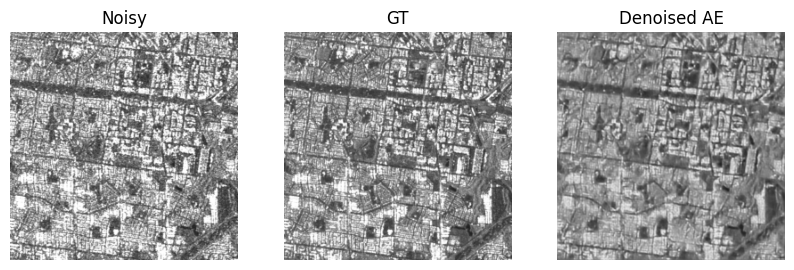

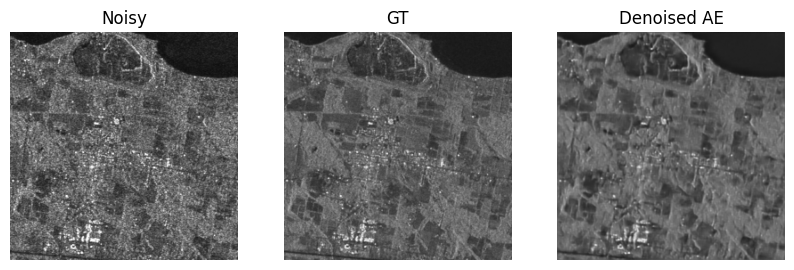

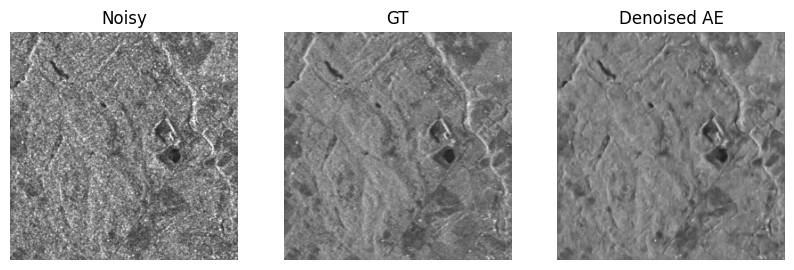

In [ ]:

for noisy, clean in val_ds.take(1):
    preds = autoencoder.predict(noisy)

for i in range(len(noisy)):
    plt.figure(figsize=(10,3))

    plt.subplot(1,3,1)
    plt.imshow(noisy[i].numpy().squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.title("Noisy")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(clean[i].numpy().squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.title("GT")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(preds[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.title("Denoised AE")
    plt.axis('off')

    plt.show()

U-NET


In [ ]:
# Construcción del modelo U-Net
def build_unet():
    inputs = layers.Input((IMG_SIZE, IMG_SIZE, 1))

    # Encoder
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(c1)  # 🔥 extra
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    u1 = layers.concatenate([u1, c2])
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c3)
    u2 = layers.concatenate([u2, c1])
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(u2)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss=combined_loss)

    return model

# Crear modelo U-Net
unet = build_unet()

# Mostrar estructura
unet.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 256, 256,  │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 256, 256,  │      9,248 │ conv2d_16[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 128, 128,  │          0 │ conv2d_17[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 128, 128,  │     18,496 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_18[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 64, 64,    │          0 │ conv2d_19[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_7[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 128, 128,  │          0 │ conv2d_20[0][0]   │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 128, 128,  │          0 │ up_sampling2d_2[… │
│ (Concatenate)       │ 192)              │            │ conv2d_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 128, 128,  │    110,656 │ concatenate_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_3     │ (None, 256, 256,  │          0 │ conv2d_21[0][0]   │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 256, 256,  │          0 │ up_sampling2d_3[… │
│ (Concatenate)       │ 96)               │            │ conv2d_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 256, 256,  │     27,680 │ concatenate_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 256, 256,  │         33 │ conv2d_22[0][0]   │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 277,217 (1.06 MB)

 Trainable params: 277,217 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento del modelo U-Net
history_unet = unet.fit(
    train_ds,             # Datos de entrenamiento (noisy → clean)
    validation_data=val_ds,  # Datos de validación para evaluar desempeño
    epochs=EPOCHS         # Número de épocas
)

Epoch 1/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 59s 112ms/step - loss: 0.1318 - val_loss: 0.1362
Epoch 2/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 36s 85ms/step - loss: 0.1129 - val_loss: 0.1345
Epoch 3/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 38s 90ms/step - loss: 0.1085 - val_loss: 0.1297
Epoch 4/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 40s 96ms/step - loss: 0.1077 - val_loss: 0.1248
Epoch 5/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 37s 85ms/step - loss: 0.1069 - val_loss: 0.1214
Epoch 6/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 38s 90ms/step - loss: 0.1050 - val_loss: 0.1270
Epoch 7/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - loss: 0.1067 - val_loss: 0.1249
Epoch 8/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 36s 88ms/step - loss: 0.1053 - val_loss: 0.1200
Epoch 9/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 37s 88ms/step - loss: 0.1054 - val_loss: 0.1231
Epoch 10/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - loss: 0.1050 - val_loss: 0.1202
Epoch 11/30
300/300 ━━━━━━━━━━━━━━━━━━━━ 40s 86ms/step - loss: 0.1073 - val_loss: 0.1218
Epoch 12/30
300/300 ━━━━━━━━━

In [ ]:
# Tomar un batch del conjunto de validación
for noisy, clean in val_ds.take(1):
    preds_unet = unet.predict(noisy)  # Predicción del U-Net

# Calcular métricas
psnr_unet, ssim_unet = compute_metrics(clean, preds_unet)

# Mostrar resultados
print("U-Net → PSNR:", psnr_unet)
print("U-Net → SSIM:", ssim_unet)
print("U-Net → ENL:", enl_roi(preds_unet[0].squeeze()))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
U-Net → PSNR: 27.162176
U-Net → SSIM: 0.7348972
U-Net → ENL: 17.30524


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


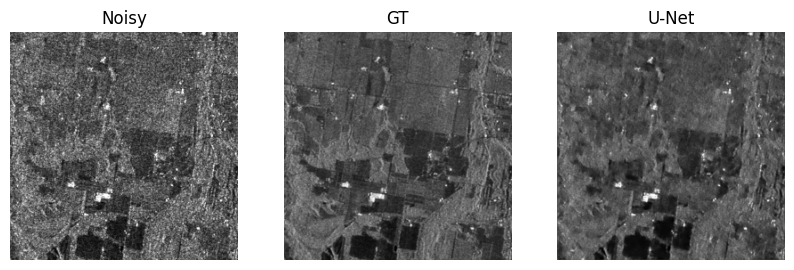

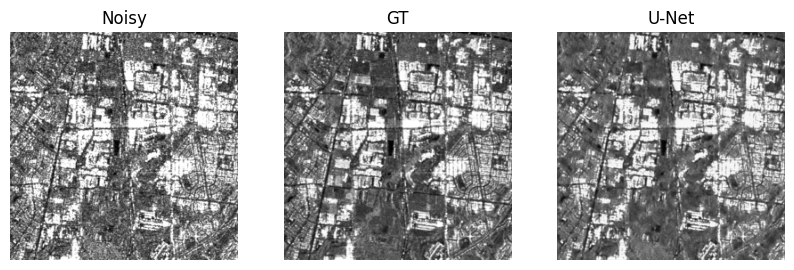

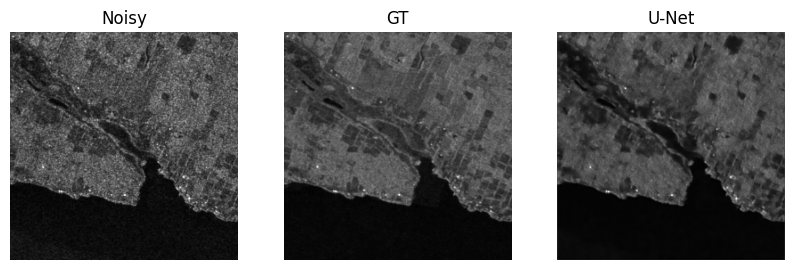

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


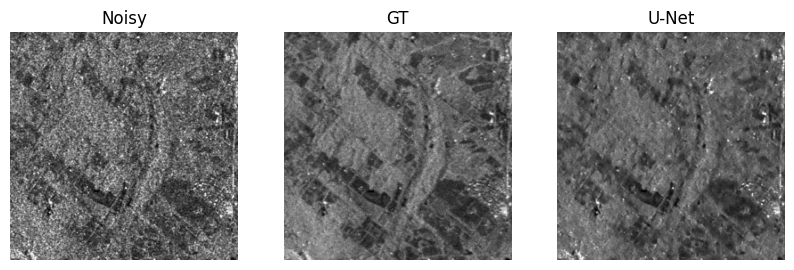

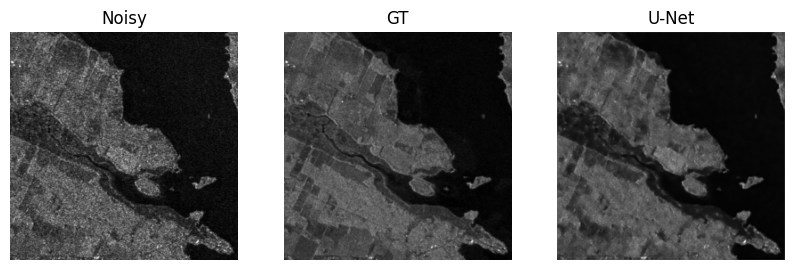

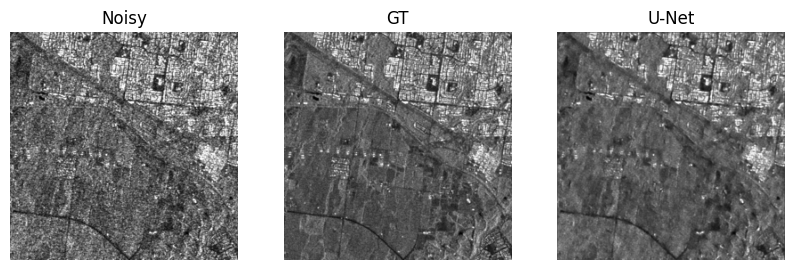

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


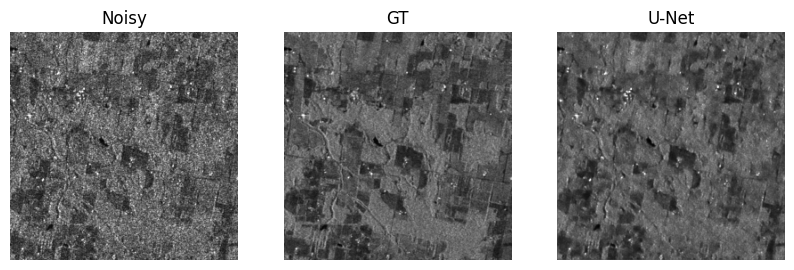

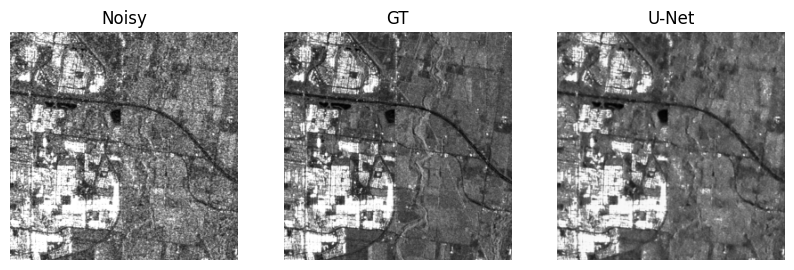

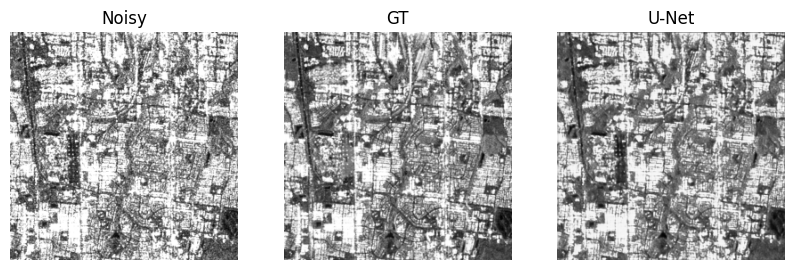

In [ ]:
# Visualizar varias imágenes del conjunto de validación
for noisy, clean in val_ds.take(3):  # Tomar 3 batches
    preds = unet.predict(noisy)      # Predicción del modelo

    for i in range(len(noisy)):  # Recorrer imágenes del batch
        plt.figure(figsize=(10,3))

        # Imagen ruidosa (entrada)
        plt.subplot(1,3,1)
        plt.imshow(noisy[i].numpy().squeeze(), cmap='gray')
        plt.title("Noisy")
        plt.axis('off')

        # Imagen original (ground truth)
        plt.subplot(1,3,2)
        plt.imshow(clean[i].numpy().squeeze(), cmap='gray')
        plt.title("GT")
        plt.axis('off')

        # Imagen reconstruida por U-Net
        plt.subplot(1,3,3)
        plt.imshow(preds[i].squeeze(), cmap='gray')
        plt.title("U-Net")
        plt.axis('off')

        plt.show()

In [ ]:
# Mostrar resultados finales de ambos modelos
print("\n--- RESULTADOS ---")

# Métricas del autoencoder
print("Autoencoder → PSNR:", psnr_ae, "| SSIM:", ssim_ae, "| ENL:", enl_roi(preds_ae[0].squeeze()))

# Métricas del U-Net
print("U-Net       → PSNR:", psnr_unet, "| SSIM:", ssim_unet, "| ENL:", enl_roi(preds_unet[0].squeeze()))


--- RESULTADOS ---
Autoencoder → PSNR: 26.714447 | SSIM: 0.761673 | ENL: 3.510478
U-Net       → PSNR: 27.162176 | SSIM: 0.7348972 | ENL: 17.30524


In [ ]:
# ---------------------------------------
# EVALUACIÓN COMPLETA SOBRE TODO val_ds
# ---------------------------------------

psnr_list_ae, ssim_list_ae, enl_list_ae = [], [], []
psnr_list_unet, ssim_list_unet, enl_list_unet = [], [], []

for noisy, clean in val_ds:

    preds_ae = autoencoder.predict(noisy, verbose=0)
    preds_unet = unet.predict(noisy, verbose=0)

    # PSNR y SSIM batch
    psnr_ae_batch, ssim_ae_batch = compute_metrics(clean, preds_ae)
    psnr_unet_batch, ssim_unet_batch = compute_metrics(clean, preds_unet)

    psnr_list_ae.append(psnr_ae_batch)
    ssim_list_ae.append(ssim_ae_batch)

    psnr_list_unet.append(psnr_unet_batch)
    ssim_list_unet.append(ssim_unet_batch)

    # ENL ROI por imagen
    for i in range(len(preds_ae)):
        enl_list_ae.append(enl_roi(preds_ae[i].squeeze()))
        enl_list_unet.append(enl_roi(preds_unet[i].squeeze()))

# Promedios finales
print("\n--- RESULTADOS CORREGIDOS (Dataset completo + ROI) ---")

print("Autoencoder → PSNR:", np.mean(psnr_list_ae),
      "| SSIM:", np.mean(ssim_list_ae),
      "| ENL:", np.mean(enl_list_ae))

print("U-Net       → PSNR:", np.mean(psnr_list_unet),
      "| SSIM:", np.mean(ssim_list_unet),
      "| ENL:", np.mean(enl_list_unet))


--- RESULTADOS CORREGIDOS (Dataset completo + ROI) ---
Autoencoder → PSNR: 25.255507 | SSIM: 0.7307106 | ENL: 77.001274
U-Net       → PSNR: 26.332228 | SSIM: 0.76813525 | ENL: 90.34299


## Análisis del Modelo 1 (Autoencoder), Modelo 2 (U-Net) y comparación entre ambos modelos

### Descripción del Modelo 1 (Autoencoder)
En esta fase se implementó un modelo Autoencoder como arquitectura base para el problema de despeckling en imágenes SAR.
El modelo utiliza una estructura secuencial encoder–decoder, donde el encoder comprime la imagen de entrada para extraer características relevantes y el decoder reconstruye la imagen intentando eliminar el ruido speckle.
La arquitectura está compuesta por capas convolucionales, operaciones de max pooling para reducción espacial y capas Conv2DTranspose para reconstrucción. Además, se empleó una función de pérdida combinada (MSE + SSIM), permitiendo optimizar simultáneamente la fidelidad pixel a pixel y la preservación estructural.

### Resultados del Modelo 1 (Autoencoder)

*   **PSNR:** 25.26
*   **SSIM:** 0.7307
*   **ENL:** 77.00

### Análisis del Modelo 1
El Autoencoder logró una mejora importante en la reducción del ruido speckle respecto a las imágenes originales, funcionando como una línea base sólida para el reto.

**Fortalezas:**

*   Buena capacidad de reconstrucción general
*   Reducción significativa de ruido
*   Estructura sencilla y funcional
*   Buen desempeño inicial para restauración SAR

**Limitaciones:**

*   Pérdida parcial de detalles finos
*   Menor preservación estructural
*   Mayor número de parámetros (739,073)
*   Mayor riesgo de sobreajuste

**Análisis de entrenamiento:**

*   Loss inicial: 0.1811
*   Loss final entrenamiento: ~0.1090
*   Val_loss final: ~0.1377

**Interpretación:**
Aunque el modelo aprende progresivamente, la diferencia entre entrenamiento y validación sugiere menor capacidad de generalización y una tendencia a reconstrucciones más suavizadas.

### Descripción del Modelo 2 (U-Net)
En esta fase se implementó una arquitectura U-Net, diseñada para mejorar la reconstrucción espacial mediante conexiones skip connection entre encoder y decoder.
A diferencia del Autoencoder, este modelo conserva información espacial de alta resolución desde etapas tempranas del encoder, permitiendo una recuperación más precisa de estructuras importantes.
La arquitectura incluye bloques convolucionales dobles, max pooling, bottleneck y upsampling con concatenación, lo que mejora significativamente la restauración de imágenes SAR.

### Resultados del Modelo 2 (U-Net)

*   **PSNR:** 26.33
*   **SSIM:** 0.7681
*   **ENL:** 90.34

### Análisis del Modelo 2
El U-Net mostró un desempeño superior en todas las métricas evaluadas, consolidándose como el modelo más robusto para despeckling SAR.

**Fortalezas:**

*   Mejor reconstrucción global
*   Mayor preservación de detalles estructurales
*   Mejor suavizado en regiones homogéneas
*   Menor cantidad de parámetros (277,217)
*   Mayor eficiencia computacional
*   Mejor estabilidad de entrenamiento

**Análisis de entrenamiento:**

*   Loss inicial: 0.1318
*   Loss final entrenamiento: ~0.1034
*   Val_loss final: ~0.1179

**Interpretación:**
El modelo converge más rápido, mantiene menor pérdida de validación y presenta una generalización más estable que el Autoencoder.

### Comparación global entre modelos

| Métrica   | Modelo 1 (Autoencoder) | Modelo 2 (U-Net) |
|:----------|:-----------------------|:-----------------|
| PSNR      | 25.26                  | 26.33            |
| SSIM      | 0.7307                 | 0.7681           |
| ENL       | 77.00                  | 90.34            |

### Comparación por métricas

**PSNR**

*   Modelo 1: 25.26
*   Modelo 2: 26.33

→ El Modelo 2 supera al Modelo 1 en aproximadamente +1.08 dB, logrando una reconstrucción más cercana a la imagen ground truth.

**SSIM**

*   Modelo 1: 0.7307
*   Modelo 2: 0.7681

→ U-Net preserva mejor bordes, estructuras y patrones espaciales, mejorando significativamente la calidad visual.

**ENL**

*   Modelo 1: 77.00
*   Modelo 2: 90.34

→ El Modelo 2 reduce mejor el speckle residual y produce regiones homogéneas más limpias.

### Comparación arquitectónica

**Modelo 1:**

*   739,073 parámetros
*   Arquitectura secuencial
*   Reconstrucción adecuada
*   Mayor complejidad computacional
*   Menor eficiencia estructural

**Modelo 2:**

*   277,217 parámetros
*   Skip connections
*   Mejor preservación espacial
*   Menor complejidad
*   Mayor eficiencia global

**Interpretación:**
Aunque el Autoencoder posee más parámetros, el diseño estructural de U-Net demuestra ser mucho más efectivo.

### Comparación de entrenamiento

**Modelo 1:**

*   Aprendizaje más lento
*   Mayor pérdida de validación
*   Mayor brecha train/validation
*   Más riesgo de sobreajuste

**Modelo 2:**

*   Convergencia más rápida
*   Menor val_loss
*   Mayor estabilidad
*   Mejor generalización

### Interpretación visual

**Modelo 1:**

*   Imágenes más suavizadas
*   Menor definición estructural
*   Posible pérdida de detalles finos

**Modelo 2:**

*   Mejor conservación de bordes
*   Mayor nitidez
*   Mejor equilibrio entre reducción de ruido y preservación espacial

### Interpretación general de los resultados
La comparación demuestra que la arquitectura influye más que el número de parámetros en problemas de restauración SAR.
Mientras el Modelo 1 cumple correctamente como base funcional, el Modelo 2 optimiza mejor el proceso de despeckling al preservar información estructural crítica.
Esto evidencia que:

*   Eliminar ruido no es suficiente
*   Preservar estructuras espaciales es fundamental
*   Las skip connections representan una mejora clave
*   U-Net ofrece una solución más robusta y eficiente

### Conclusiones finales

*   **El Modelo 1 (Autoencoder) fue una línea base funcional y adecuada.**
    *   Demostró capacidad para reducir ruido y reconstruir imágenes SAR, pero presentó limitaciones en preservación estructural.

*   **El Modelo 2 (U-Net) superó claramente al Modelo 1.**
    *   Obtuvo mejores resultados en PSNR, SSIM y ENL, ofreciendo mejor desempeño cuantitativo y cualitativo.

*   **La arquitectura fue más importante que la cantidad de parámetros.**
    *   Aunque el Autoencoder era más grande, U-Net logró mejores resultados con una estructura más eficiente.

*   **Las skip connections fueron determinantes.**
    *   Permitieron preservar mejor información espacial, mejorando significativamente la calidad final.

*   **U-Net representó el mejor balance entre precisión, generalización y eficiencia.**
    *   Para tareas de despeckling SAR, se posiciona como una solución más robusta que el Autoencoder tradicional.

*   **En restauración de imágenes SAR, modelos orientados a preservación espacial ofrecen ventajas claras.**
    *   Esto confirma que arquitecturas más especializadas pueden superar modelos secuenciales clásicos incluso con menor complejidad computacional.

## Comparación de resultados con el artículo IEEE 2024 y relación con el desarrollo realizado

Como parte del análisis final del reto, se realizó una comparación entre los resultados obtenidos en este proyecto y la metodología presentada en el artículo IEEE 2024 “A New Methodology for Assessing SAR Despeckling Filters”, con el fin de validar si el enfoque implementado se encuentra alineado con investigaciones recientes en despeckling SAR.

El artículo plantea que los modelos de aprendizaje profundo para reducción de speckle deben entrenarse y evaluarse preferiblemente con imágenes SAR reales, utilizando ground truths generados mediante multitemporal fusion, en lugar del enfoque tradicional basado en imágenes ópticas con ruido sintético. Los autores demostraron que un Autoencoder entrenado con SAR real mejora significativamente métricas como PSNR, SSIM y ENL frente a métodos sintéticos y filtros tradicionales como FANS.

En el desarrollo realizado para este reto, el Modelo 1 (Autoencoder) siguió una filosofía similar, utilizando pares de imágenes Noisy/Ground Truth para entrenamiento supervisado y evaluando el desempeño mediante PSNR, SSIM y ENL. Esto permitió replicar conceptualmente el enfoque base del artículo, donde el Autoencoder funciona como línea inicial de referencia para despeckling SAR.

Los resultados obtenidos con el Modelo 1 mostraron un desempeño adecuado:

*   PSNR: 25.26
*   SSIM: 0.7307
*   ENL: 77.00

Estos resultados confirman que el Autoencoder constituye una base funcional para reducción de speckle, coherente con lo planteado en el documento IEEE, donde esta arquitectura se propone como punto de partida para futuras mejoras estructurales.

Sin embargo, en este proyecto no se limitó el análisis al Autoencoder, sino que se avanzó hacia una arquitectura más robusta mediante el Modelo 2 (U-Net), incorporando skip connections para mejorar la preservación espacial. Esta decisión permitió extender el enfoque del artículo, explorando precisamente una de las líneas de mejora sugeridas por los autores: optimizar la arquitectura base.

El Modelo 2 obtuvo mejores resultados en todas las métricas:

*   PSNR: 26.33
*   SSIM: 0.7681
*   ENL: 90.34

La comparación directa evidenció que U-Net superó al Autoencoder en reconstrucción, preservación estructural y reducción de speckle, demostrando que no solo el tipo de dataset influye en el desempeño, sino también la arquitectura utilizada.

Desde una perspectiva crítica, el artículo se enfocó principalmente en demostrar que el uso de datasets SAR reales es superior al protocolo sintético tradicional, mientras que en este reto el énfasis estuvo en comparar arquitecturas dentro del proceso de despeckling. Por ello, el trabajo desarrollado complementa el artículo: primero valida el uso del Autoencoder como baseline, y luego demuestra que arquitecturas más avanzadas como U-Net pueden mejorar significativamente dicho baseline.

### Conclusión comparativa con IEEE

A partir de esta comparación, se puede concluir que el desarrollo realizado cumple con los fundamentos metodológicos planteados en la literatura reciente y, además, los amplía mediante una comparación arquitectónica más profunda.

**Principales conclusiones:**
1.  El Modelo 1 (Autoencoder) validó correctamente el enfoque base del artículo.
    Su desempeño fue consistente con la propuesta IEEE, funcionando como una arquitectura inicial adecuada para despeckling SAR.

2.  El Modelo 2 (U-Net) representó una mejora clara sobre el baseline.
    La incorporación de skip connections permitió mejores resultados en PSNR, SSIM y ENL, confirmando que mejorar la arquitectura puede potenciar significativamente el rendimiento.

3.  El trabajo realizado confirma que el dataset y la arquitectura son factores complementarios.
    El artículo enfatiza la importancia del dataset SAR real, mientras que este proyecto demuestra que una arquitectura más especializada puede explotar mejor dicho entorno.

4.  Los resultados obtenidos se alinean con la dirección futura sugerida por IEEE.
    El artículo propone que el Autoencoder puede servir como base para estructuras más avanzadas; en este reto, U-Net confirmó precisamente esa hipótesis.

**Conclusión final:**

El desarrollo realizado no solo replicó principios actuales de investigación en despeckling SAR, sino que también evidenció que el siguiente paso lógico después de un Autoencoder baseline es el uso de arquitecturas optimizadas como U-Net. Por tanto, el mejor enfoque para futuras aplicaciones sería combinar metodologías de evaluación realistas, como las propuestas por IEEE, con modelos de mayor capacidad estructural, logrando así una solución más robusta, generalizable y eficiente para reducción de speckle en imágenes SAR.